# SFA vs Raw Feature Visualisation

Generate a publication-ready plot showing raw audio features overlaid with SFA-derived slow features for a single participant, illustrating how SFA extracts slowly varying signals from noisy data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Load data
raw_features = np.load('features/raw_features.npy')
participant_ids = np.load('features/participant_ids.npy')
slow_linear = np.load('features/slow_linear_audio_10.npy')
slow_deg2 = np.load('features/slow_deg2_audio_10.npy')

# Pick one participant
pid = np.unique(participant_ids)[0]
mask = participant_ids == pid
n_steps = mask.sum()

print(f'Participant: {int(pid)}')
print(f'Time steps: {n_steps}')

Participant: 16
Time steps: 729


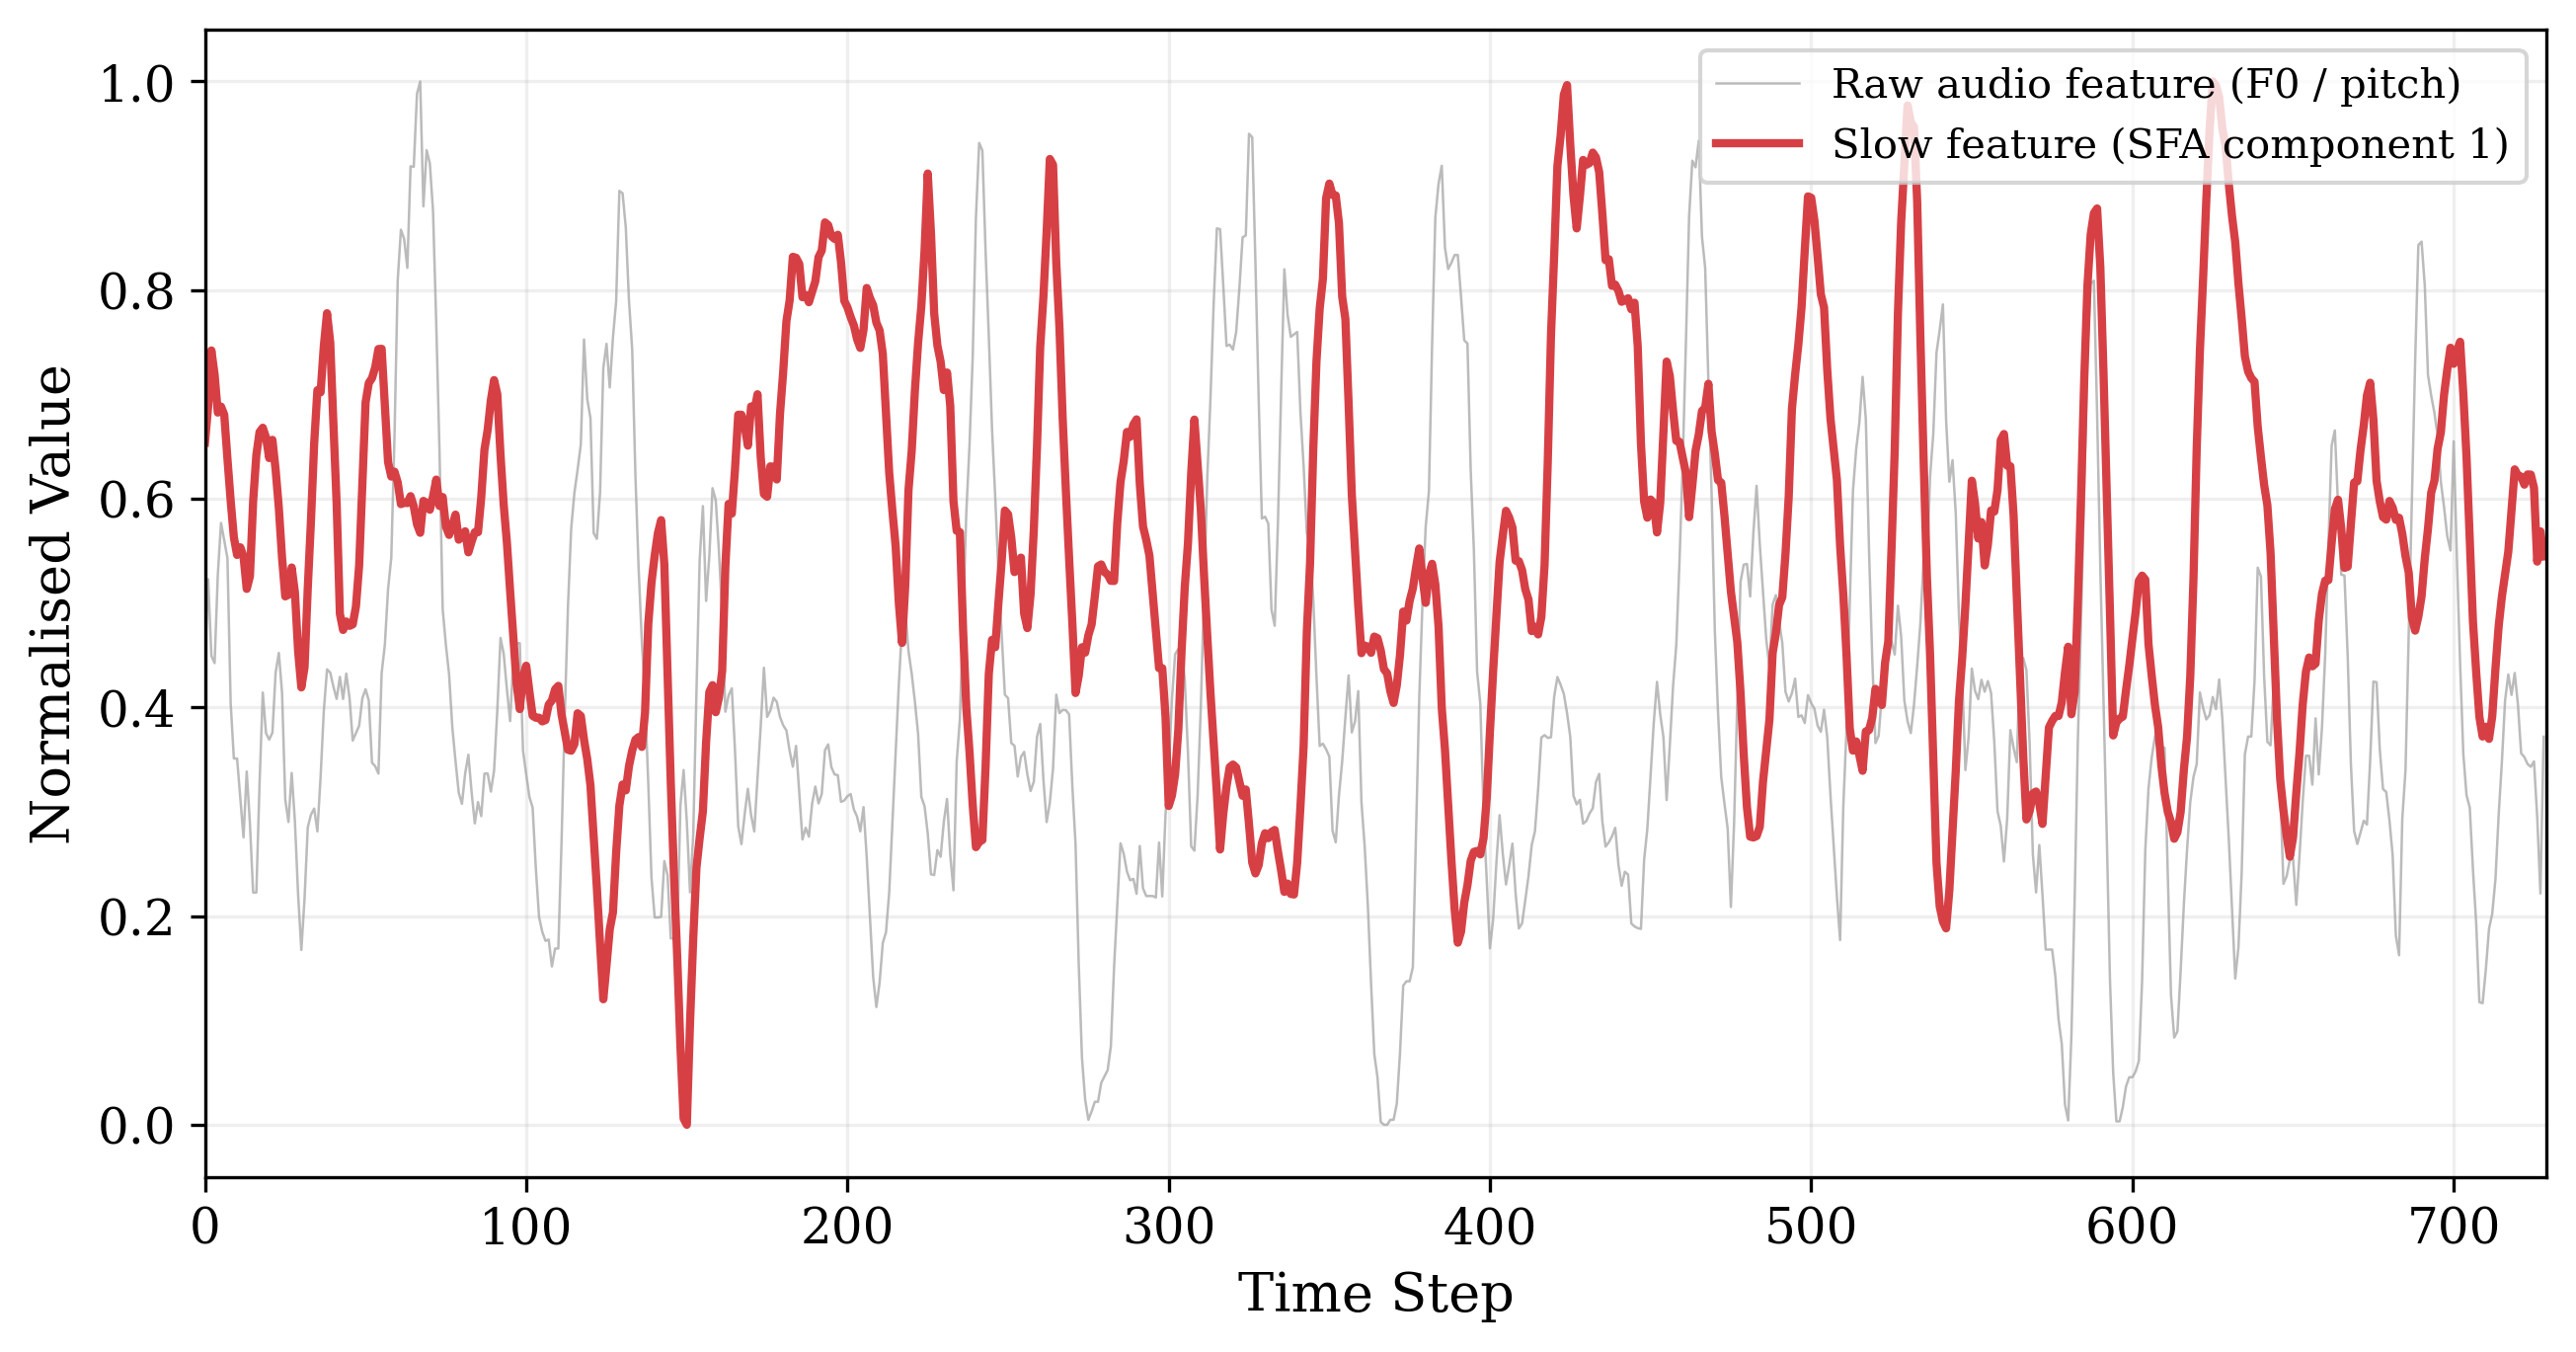

Saved: features/sfa_vs_raw_simple.png


In [8]:
# --- Plot 1: Single raw feature vs single slow feature (simplest comparison) ---
# This is the clearest image for a non-technical audience

raw = raw_features[mask, 0]  # F0 (fundamental frequency / pitch)
slow = slow_linear[mask, 0]  # Slowest linear SFA component

# Normalise both to [0, 1] range for visual comparison
raw_norm = (raw - raw.min()) / (raw.max() - raw.min())
slow_norm = (slow - slow.min()) / (slow.max() - slow.min())

time = np.arange(n_steps)

fig, ax = plt.subplots(figsize=(15/2.54 * 1.5, 8/2.54 * 1.5))  # ~15cm wide

ax.plot(time, raw_norm, color='#AAAAAA', linewidth=0.6, alpha=0.8, label='Raw audio feature (F0 / pitch)')
ax.plot(time, slow_norm, color='#D64045', linewidth=2.0, label='Slow feature (SFA component 1)')

ax.set_xlabel('Time Step')
ax.set_ylabel('Normalised Value')
ax.legend(loc='upper right')
ax.set_xlim(0, n_steps)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('features/sfa_vs_raw_simple.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: features/sfa_vs_raw_simple.png')

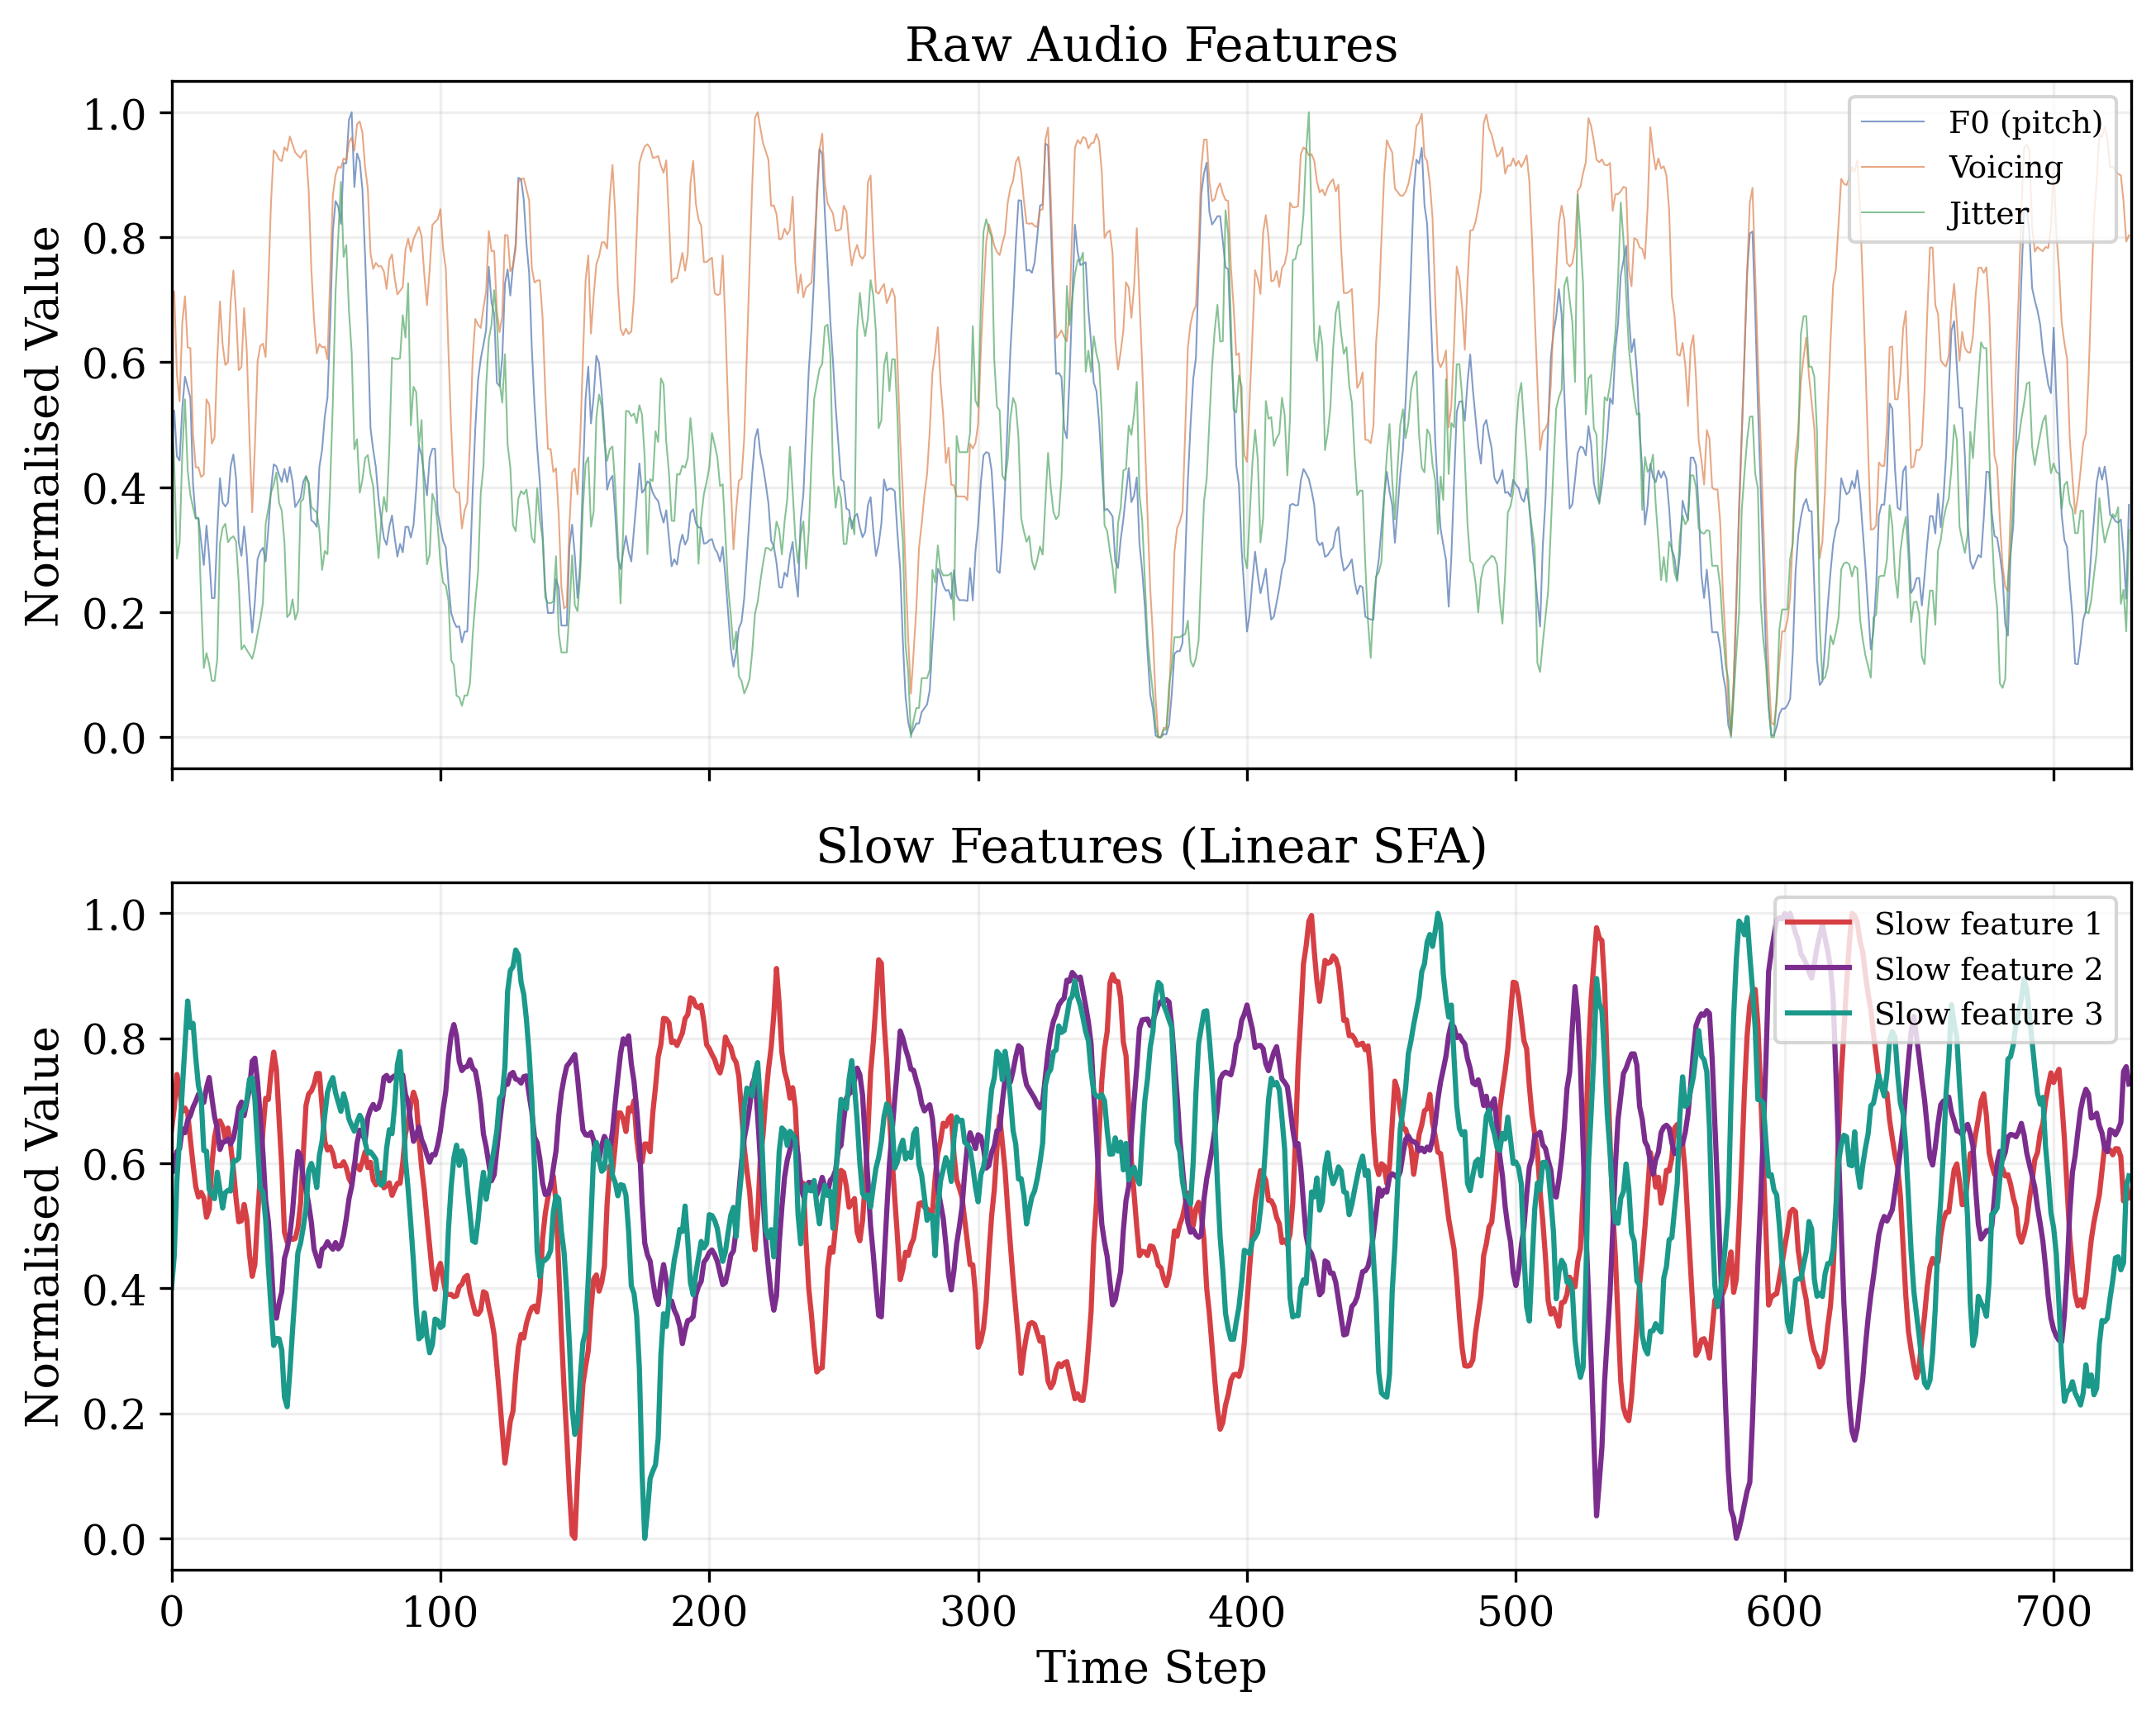

Saved: features/sfa_vs_raw_panels.png


In [4]:
# --- Plot 2: Two-panel version (raw on top, slow features below) ---

fig, axes = plt.subplots(2, 1, figsize=(15/2.54 * 1.5, 12/2.54 * 1.5), sharex=True)

# Top panel: 3 raw features
labels_raw = ['F0 (pitch)', 'Voicing', 'Jitter']
colours_raw = ['#4C72B0', '#DD8452', '#55A868']
for i in range(3):
    r = raw_features[mask, i]
    r_norm = (r - r.min()) / (r.max() - r.min())
    axes[0].plot(time, r_norm, color=colours_raw[i], linewidth=0.5, alpha=0.7, label=labels_raw[i])

axes[0].set_ylabel('Normalised Value')
axes[0].set_title('Raw Audio Features')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(alpha=0.2)

# Bottom panel: 3 slowest SFA components
colours_sfa = ['#D64045', '#7B2D8E', '#1B998B']
for i in range(3):
    s = slow_linear[mask, i]
    s_norm = (s - s.min()) / (s.max() - s.min())
    axes[1].plot(time, s_norm, color=colours_sfa[i], linewidth=1.5, label=f'Slow feature {i+1}')

axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Normalised Value')
axes[1].set_title('Slow Features (Linear SFA)')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(alpha=0.2)
axes[1].set_xlim(0, n_steps)

plt.tight_layout()
plt.savefig('features/sfa_vs_raw_panels.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: features/sfa_vs_raw_panels.png')

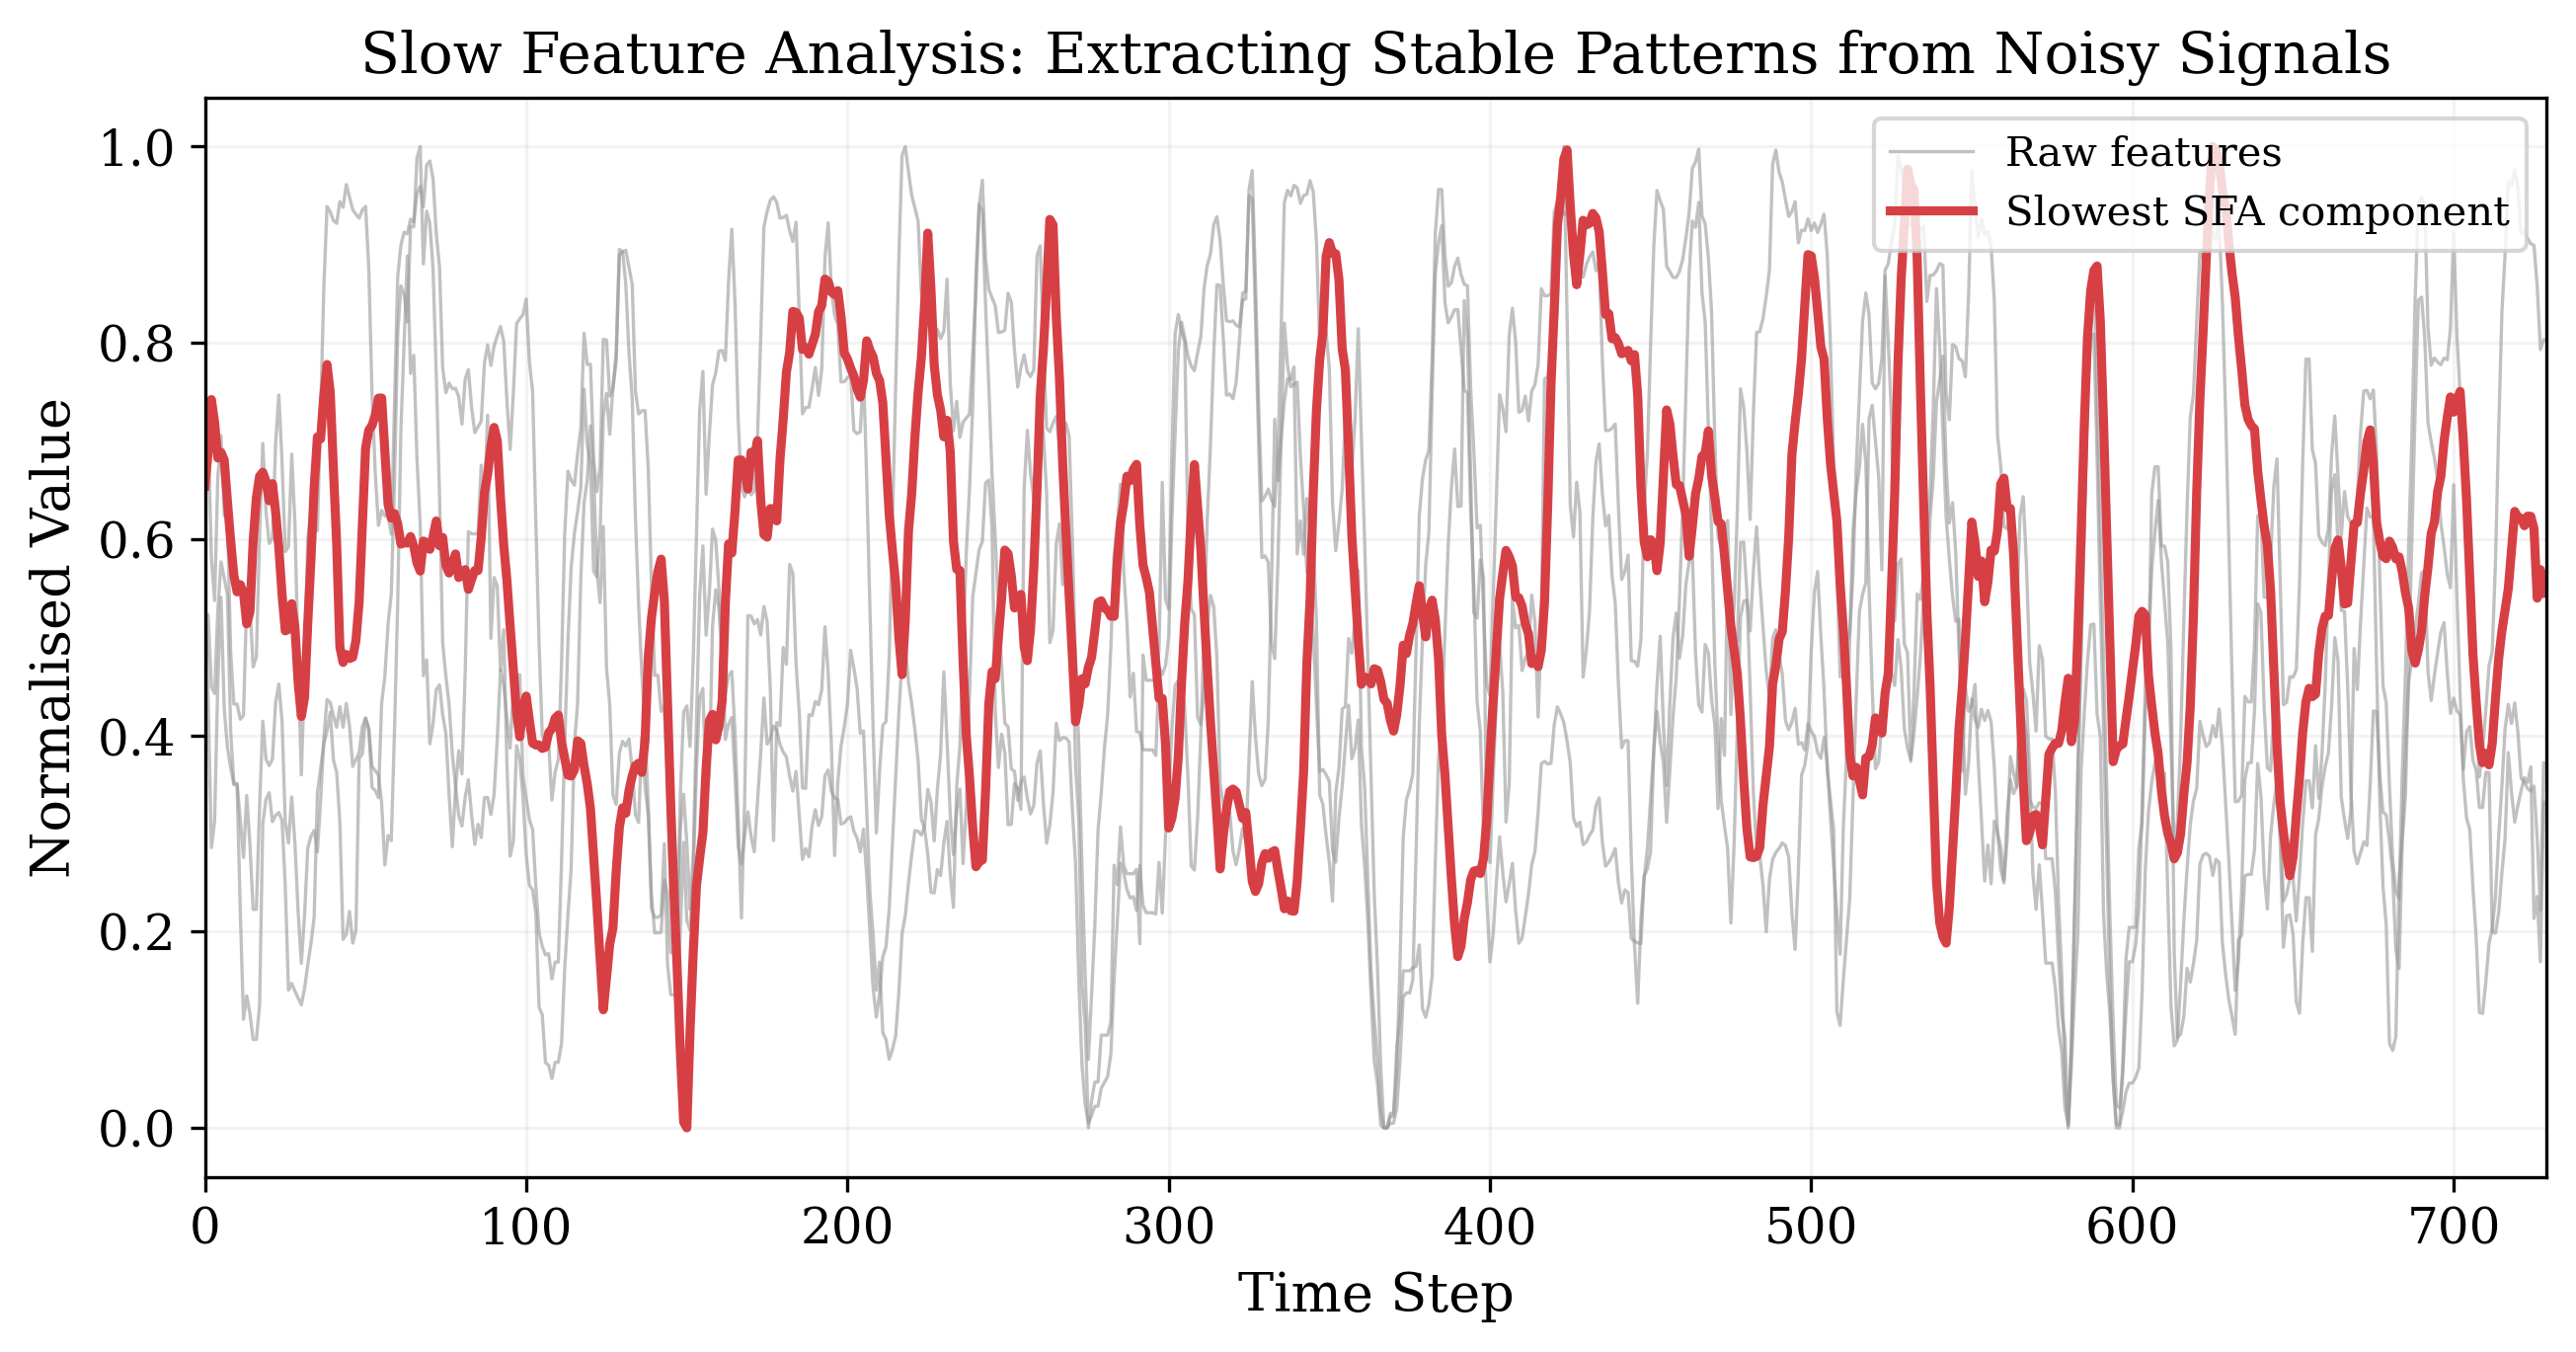

Saved: features/sfa_vs_raw_overlay.png


In [7]:
# --- Plot 3: Overlay on same axes (raw as background, SFA in foreground) ---
# Most dramatic visual contrast

fig, ax = plt.subplots(figsize=(15/2.54 * 1.5, 8/2.54 * 1.5))

# Plot 3 raw features as faint background
for i in range(3):
    r = raw_features[mask, i]
    r_norm = (r - r.min()) / (r.max() - r.min())
    lbl = labels_raw[i] if i == 0 else None
    ax.plot(time, r_norm, color="#989898", linewidth=0.8, alpha=0.6,
            label='Raw features' if i == 0 else None)

# Overlay slowest SFA component
s = slow_linear[mask, 0]
s_norm = (s - s.min()) / (s.max() - s.min())
ax.plot(time, s_norm, color='#D64045', linewidth=2.2, label='Slowest SFA component')

ax.set_xlabel('Time Step')
ax.set_ylabel('Normalised Value')
ax.set_title('Slow Feature Analysis: Extracting Stable Patterns from Noisy Signals')
ax.legend(loc='upper right')
ax.set_xlim(0, n_steps)
ax.grid(alpha=0.15)

plt.tight_layout()
plt.savefig('features/sfa_vs_raw_overlay.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: features/sfa_vs_raw_overlay.png')